Enter the initial 'a' value:  0
Enter the number of iterations:  20


Finding a valid b value...
Found valid interval: [0.0, 4.587114111412207] with opposite signs.
Iteration 1:
Current interval: [0.0, 4.587114111412207]
f(c) = 1.966846912073147
Replacing b with c. New interval: [0.0, 2.2935570557061036]
Iteration 2:
Current interval: [0.0, 2.2935570557061036]
f(c) = -0.8316775359082391
Replacing a with c. New interval: [1.1467785278530518, 2.2935570557061036]
Iteration 3:
Current interval: [1.1467785278530518, 2.2935570557061036]
f(c) = 0.23880944009625105
Replacing b with c. New interval: [1.1467785278530518, 1.7201677917795777]
Iteration 4:
Current interval: [1.1467785278530518, 1.7201677917795777]
f(c) = -0.378627859902545
Replacing a with c. New interval: [1.4334731598163146, 1.7201677917795777]
Iteration 5:
Current interval: [1.4334731598163146, 1.7201677917795777]
f(c) = -0.0904576629022853
Replacing a with c. New interval: [1.576820475797946, 1.7201677917795777]
Iteration 6:
Current interval: [1.576820475797946, 1.7201677917795777]
f(c) = 0.06903

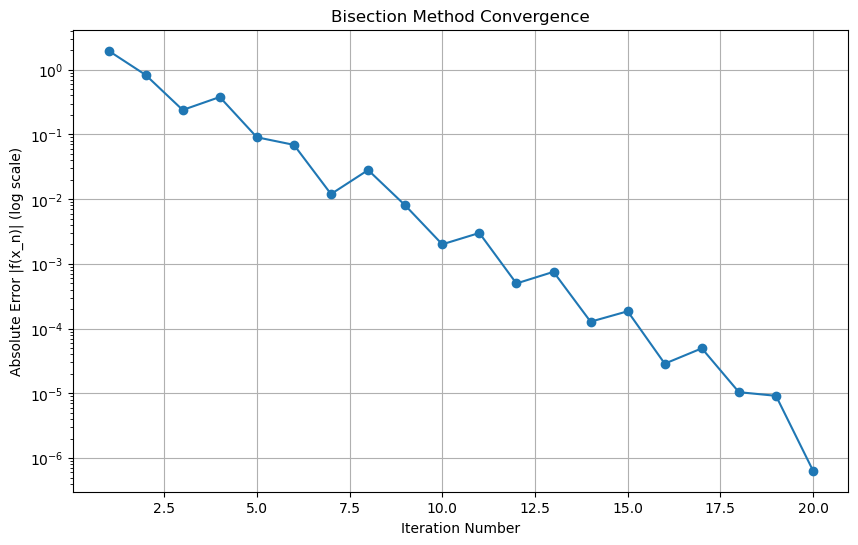

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random

def bisection(func, a_init, iterations):
    def f(x):
        return eval(func)

    a = a_init
    b = a_init

    print("Finding a valid b value...")
    while True:
        b = random.uniform(a - 10, a + 10)
        if f(a) * f(b) < 0:
            print(f"Found valid interval: [{a}, {b}] with opposite signs.")
            break
        print(f"Trying b = {b}: f(a) * f(b) > 0, looking for another b...")

    error_list = []  # To store absolute error values

    for i in range(iterations):
        c = (a + b) / 2
        error = abs(f(c))
        error_list.append(error)

        print(f"Iteration {i + 1}:")
        print(f"Current interval: [{a}, {b}]")
        print(f"f(c) = {f(c)}")

        if f(c) == 0:
            print(f"Exact root found at x = {c}")
            return c, error_list
        elif f(a) * f(c) < 0:
            b = c
            print(f"Replacing b with c. New interval: [{a}, {b}]")
        else:
            a = c
            print(f"Replacing a with c. New interval: [{a}, {b}]")

    return c, error_list  # Return the approximate root and error list

# Example usage
a_init = float(input("Enter the initial 'a' value: "))
iterations = int(input("Enter the number of iterations: "))
result, errors = bisection("x**2 - x - 1", a_init, iterations)

print(f"Approximate root: {result}")

plt.figure(figsize=(10, 6))
plt.semilogy(range(1, iterations + 1), errors, marker='o')
plt.title("Bisection Method Convergence")
plt.xlabel("Iteration Number")
plt.ylabel("Absolute Error |f(x_n)| (log scale)")
plt.grid(True)
plt.show()